In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
device="cuda:0" if torch.cuda.is_available() else "cpu"
device

'cuda:0'

In [3]:
# 1

In [4]:
# 1. 데이터 로드 및 구조 분석 
#  nodulemnist3d.npz 파일을 로드하시오.

In [5]:
df=np.load("./nodulemnist3d.npz")

In [6]:
# 2. 데이터셋을 불러와 (numpy.load()) 아래 key들을 출력하시오.

In [7]:
df.files

['train_images',
 'train_labels',
 'val_images',
 'val_labels',
 'test_images',
 'test_labels']

In [8]:
# 3. train_images.shape 를 출력하고 의미를 설명하시오.

In [9]:
df['train_images'].shape

(1158, 28, 28, 28)

In [10]:
# 1158: 총 이미지의 개수
# 28 : 이미지의 세로 길이
# 28 : 이미지의 가로 길이
# 28 : 이미지의 차원 크기

In [11]:
# 4. 데이터 하나를 matplotlib로 시각화하시오. (ex ) train_images[0] - sample[14] ) : 첫 번째 CT 데이터 선택하고 가장 가운데인 14번째 선택해서 시각화)

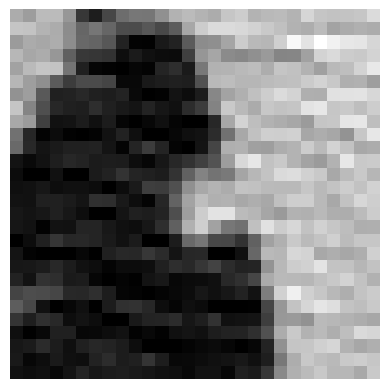

In [12]:
plt.imshow(df['train_images'][0][14], cmap='gray')
plt.axis('off')
plt.show()

In [13]:
# 5. 출력된 CT 데이터가 구조  (Depth, Height, Width)  대해 설명하시오.

In [14]:
df['train_images'][0][14].shape

(28, 28)

In [15]:
# Depth 14 : 14번째 데이터
# Height 28: 세로 28
# Width 24 : 가로 28

In [16]:
# 2

In [17]:
# 1. 아래 기능을 수행하는 Dataset 클래스를 구현하시오.
# - CT 이미지 정규화
# - Tensor 변환
# - channel dimension 추가

In [18]:
import torch
import torchvision
from torchvision import datasets
from torch.utils.data import TensorDataset
from PIL import Image
from torchvision import transforms
from torchvision.transforms import Compose, Resize, RandomHorizontalFlip, ToTensor,Normalize

In [19]:
train_images=df['train_images']
train_labels=df['train_labels']
val_images=df['val_images']
val_labels=df['val_labels']
test_images=df['test_images']
test_labels=df['test_labels']

In [20]:
train_transform=Compose([
    Resize(size=(28,28)),
    ToTensor(),
    Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))
])

val_transform=Compose([
    Resize(size=(28,28)),
    ToTensor(),
    Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))
])

test_transform=Compose([
    Resize(size=(28,28)),
    ToTensor(),
    Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))
])

In [21]:
train_tensors = torch.tensor(train_images, dtype=torch.float32)
val_tensors = torch.tensor(val_images, dtype=torch.float32)
test_tensors = torch.tensor(test_images, dtype=torch.float32)

In [22]:
train_data=TensorDataset(train_tensors, train_transform)
val_data=TensorDataset(val_tensors, val_transform)
test_data=TensorDataset(test_tensors, test_transform)

AttributeError: 'Compose' object has no attribute 'size'

In [ ]:
# 2. 다음 형태로 변환하시오. (CNN에 맞게 채널 차원 필요)

In [ ]:
train_data = train_data.unsqueeze(1)
val_data = val_data.unsqueeze(1)

In [ ]:
# 3. DataLoader를 구현하시오.

# 조건:

# - batch_size=16
# - shuffle=True(train만)

In [ ]:
train_loader=torch.utils.data.DataLoader(train_tensors, batch_size=16, shuffle=True)
val_loader=torch.utils.data.DataLoader(val_tensors, batch_size=16, shuffle=False)

In [ ]:
# 3.
# 1. 아래 layer를 반드시 포함하시오.
# - Conv3D
# - BatchNorm3D
# - ReLU
# - MaxPool3D
# - Dropout

In [ ]:
class Nodulemnist(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1=nn.Conv3d(in_channels=1, out_channels=6, kernel_size=5, padding=2)
    self.conv2=nn.Conv3d(in_channels=6, out_channels=16, kernel_size=5)
    self.maxpool=nn.MaxPool3d(2)
    self.relu=nn.ReLU()
    self.drop1=nn.dropout(p=0.2)
    self.fc1=nn.Linear(28*28*28, 120)
    self.fc2=nn.Linear(120,84)
    self.fc3=nn.Linear(84,10)

  def forward(self, x):
    x=self.relu(self.conv1(x))
    x=self.maxpool(x)
    x=self.relu(self.conv2(x))
    x=self.maxpool(x)
    x=torch.flatten(x,1)
    x=self.relu(self.fc1(x))
    x=self.drop1(x)
    x=self.relu(self.fc2(x))
    x=self.drop1(x)
    out=self.fc3(x)
    return out     

model=Nodulemnist()

In [ ]:
# 2. 아래 내용 설명하시오.
# - BatchNorm의 역할은?
# 인공 신경망의 학습을 안정화하고 속도를 높이기 위해 사용
# - Dropout을 사용하는 이유는?
# 과적합을 방지하기 위해 사용

In [ ]:
# 4.
# 1. Loss function으로 CrossEntropyLoss 를 사용하시오.
# 2. Optimizer로 Adam을 사용하시오.

# 조건:

# - learning rate = 0.001

In [ ]:
crossloss=torch.nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(resnet.parameters(), lr=0.001)

In [ ]:
# 3. epoch 학습 함수를 구현하시오.

# 포함:

# - loss 계산
# - backward
# - optimizer step

In [ ]:
def ImageTrain(epochs):
    Train Loss, Validation Loss=[], []
    for epoch in range(epochs):
        model.train()
        t_loss=0
        v_loss=0
    
        for i,j in train_loader:
            i,j=i.to(device), j.to(device)
    
            z=model(i)
            loss=crossloss(z,j)
            t_loss+=loss.item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()


        model.eval()

        with torch.inference_mode():
          for i,j in val_loader:
        
            i,j=i.to(device), j.to(device)
            z=model(i)
            loss=crossloss(z,j)
            v_loss+=loss.item()
              
        t_loss=t_loss/len(train_loader)
        v_loss=v_loss/len(val_loader)    
    
        Train Loss.append(t_loss)
        Validation Loss.append(v_loss)
        print(Train Loss)
        print(Validation Loss)

In [ ]:
# 4. 매 epoch마다 아래를 출력하시오. (총 에폭 수: 10)

In [ ]:
ImageTrain(10)

In [ ]:
# 5.
# Validation/Test 데이터에 대해 Accuracy, F1 Score를 계산하시오.

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

In [ ]:
model.eval()

with torch.no_grad():
    accuracy_score()
    f1_score()

In [ ]:
# 6.
# 1. Validation F1-score 기준으로 최고 성능 모델을 저장하시오. (파일명: best_3dcnn.pt)
# 2. 학습 종료 후 저장된 모델을 다시 불러오시오.
# 3. 불러온 모델로 test evaluation을 수행하시오.